# 03 - Material Synthesis and Optimization (CuPy Accelerated Evaluation)

In this final notebook, we pivot from prediction to discovery. We will merge the physical property features with their precise chemical compositions to train a surrogate Random Forest model. 

Then, we will employ Bayesian Optimization to navigate the vast combinatorial space of elements to propose novel superconductive alloys. We will evaluate our surrogate model's performance using `cupy` for GPU acceleration.

In [1]:
import numpy as np
import pandas as pd
import cupy as cp
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from skopt import gp_minimize
from skopt.space import Integer
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from tqdm import tqdm

## Data Integration

We load `train.csv` (physical properties) and `unique_m.csv` (elemental composition). The composition dataset records the fractional presence of elements. For our combinatorial search, we simplify this into a binary presence (0 or 1). 

After joining the datasets, we perform an 80/20 split and push the testing target to the GPU for our initial surrogate model evaluation.

In [2]:
# Load datasets
train_data = pd.read_csv('train.csv')
unique_materials = pd.read_csv('unique_m.csv')

# Remove target from composition data to prevent overlap
if 'critical_temp' in unique_materials.columns:
    unique_materials.drop(columns=['critical_temp'], inplace=True)

# Convert material quantities to binary indicators (0 or 1)
composition_features = unique_materials.columns[:-1].tolist()
unique_materials[composition_features] = (unique_materials[composition_features] > 0).astype(int)

# Merge datasets horizontally
data = pd.concat([train_data, unique_materials], axis=1)
print(f"Merged Data Shape: {data.shape}")

# Define feature matrix and target vector
X = data.drop(columns=['critical_temp', 'material'])
y = data['critical_temp']

# Train/Test Split (CPU)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Push target to GPU for accelerated metrics
y_test_cp = cp.asarray(y_test.values)

Merged Data Shape: (21263, 169)


## Surrogate Model Training

We instantiate a Random Forest Regressor to act as our surrogate physics engine. We configure it with `n_estimators=100` and `max_depth=10` to keep predictions fast during the iterative optimization loop. We evaluate its baseline accuracy using `cupy`.

In [3]:
# Train Surrogate Model
rf_surrogate = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_surrogate.fit(X_train, y_train)

# Generate test predictions
predictions = rf_surrogate.predict(X_test)

# GPU-Accelerated Evaluation
predictions_cp = cp.asarray(predictions)
rmse_cp = cp.sqrt(cp.mean((y_test_cp - predictions_cp)**2))

print(f"Surrogate Model RMSE: {float(rmse_cp):.2f}")

Surrogate Model RMSE: 10.36


## Bayesian Optimization Setup & Constraints

We define a binary search space across all 86 elements. To ensure our generated alloys are scientifically plausible, we construct an objective function heavily penalized by two constraints:
1.  **Maximum Components:** Restricting the alloy to a maximum of 3 elements.
2.  **Transition Metals:** Enforcing the presence of at least one transition metal, a common trait in high-$T_c$ superconductors.

In [4]:
# Define search space (binary selection for each element)
search_space = [Integer(0, 1, name=feature) for feature in composition_features]

MAX_COMPONENTS = 3
transition_metals = [
    'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 
    'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd'
]

@use_named_args(search_space)
def objective(**kwargs):
    # Construct candidate composition array
    candidate_composition = np.array([kwargs[feature] for feature in composition_features]).reshape(1, -1)
    candidate_features = pd.DataFrame(candidate_composition, columns=composition_features)
    
    # Pad missing statistical features with 0 for the surrogate model
    for col in X.columns:
        if col not in candidate_features:
            candidate_features[col] = 0
            
    candidate_features = candidate_features[X.columns]
    
    # Predict Tc
    predicted_tc = rf_surrogate.predict(candidate_features)[0]
    
    # Apply Scientific Constraints
    num_components = sum(kwargs[feature] for feature in composition_features)
    contains_tm = any(kwargs[element] == 1 for element in transition_metals if element in kwargs)
    
    penalty = 0
    if num_components > MAX_COMPONENTS:
        penalty += (num_components - MAX_COMPONENTS) * 1.8
    if not contains_tm:
        penalty += 50
        
    # gp_minimize seeks the minimum, so we invert predicted_tc and apply penalties
    return float(max(-predicted_tc + penalty, -100))

## Execution and Convergence Analysis

We execute the `gp_minimize` function over 180 calls, allowing it to explore the defined boundaries and exploit the highest yielding combinations. Finally, we plot the convergence trajectory to ensure the optimizer settled into a stable minimum (maximum $T_c$).

Optimizing Alloys: 100%|██████████████████████| 180/180 [17:59<00:00,  6.00s/it]


Optimal Binary Composition: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Chemical Formula of Optimal Material: CaZnSrYMoEuPt
Predicted Tc: 25.53 K


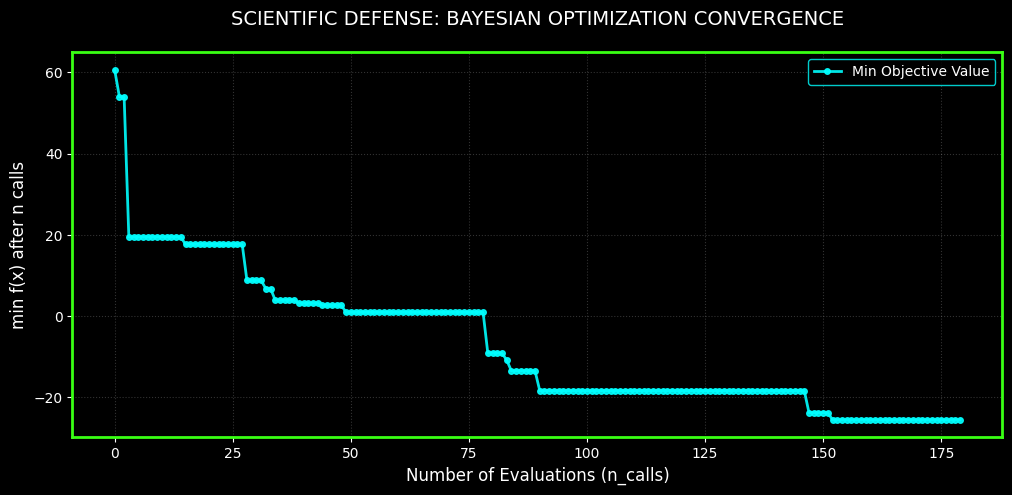

In [6]:
n_calls = 180

with tqdm(total=n_calls, desc="Optimizing Alloys") as pbar:
    def callback(res):
        pbar.update(1)
        
    result = gp_minimize(
        objective,
        search_space,
        n_calls=n_calls,
        random_state=42,
        callback=[callback]
    )

# Extract optimal configuration
optimal_candidate = result.x
optimal_tc = -result.fun

optimal_formula = "".join(
    f"{element}" if included else "" 
    for element, included in zip(composition_features, optimal_candidate)
)

print(f"\nOptimal Binary Composition: {optimal_candidate}")
print(f"Chemical Formula of Optimal Material: {optimal_formula}")
print(f"Predicted Tc: {optimal_tc:.2f} K")

# SCIENTIFIC DEFENSE STYLING: Convergence Plot
minimums = np.minimum.accumulate(result.func_vals)

plt.figure(figsize=(12, 5), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.plot(minimums, color='#00FFFF', linewidth=2, label='Min Objective Value', alpha=0.9, marker='o', markersize=4)

plt.title("SCIENTIFIC DEFENSE: BAYESIAN OPTIMIZATION CONVERGENCE", color='white', fontsize=14, pad=20)
plt.xlabel("Number of Evaluations (n_calls)", color='white', fontsize=12)
plt.ylabel("min f(x) after n calls", color='white', fontsize=12)
ax.tick_params(axis='both', colors='white', labelsize=10)

for spine in ax.spines.values():
    spine.set_color('#39FF14') 
    spine.set_linewidth(2)

plt.legend(facecolor='black', labelcolor='white', edgecolor='#00FFFF')
plt.grid(True, linestyle=':', alpha=0.2, color='white')
plt.show()